In [8]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from scipy.linalg import block_diag
import scipy as sc
import sympy as sp


import rover as rover_class
import grid_world
from astar_plan import AStarPlanner

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


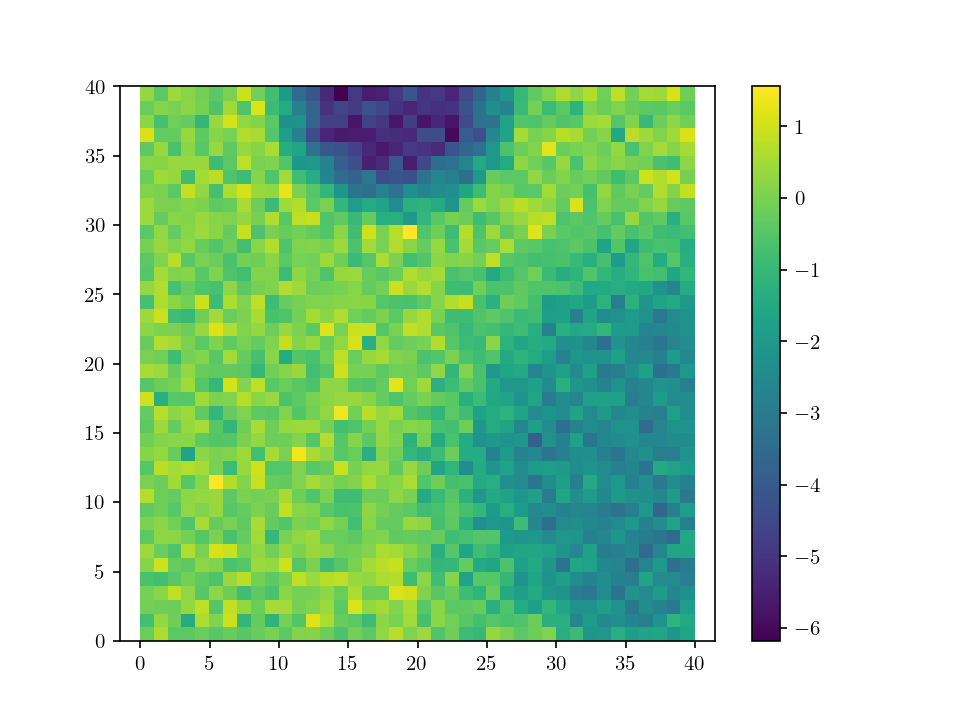

In [11]:
# rover
# assume the user is at the Poincare crater (in rad)
lat_user = np.deg2rad(-59.12448)
lon_user = np.deg2rad(161.05104)
# can initialize the rover with the desired initial location
rover = rover_class.Rover_Agent([lat_user, lon_user])
# TODO: need to make the state actually the rover state
rover_state = rover.rover_loc

N_t = 100          # number of time steps

# create a grid (specify number of cells and cell resolution)
grid_env = grid_world.GridWorld(40, 1, N_t, rover.rover_loc, 0.0, 0.5)
# let's add some craters (if you do not specify location, they will be randomly placed)
crater = grid_env.create_crater(10, 5)
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(20, 2.5)
grid_env.add_crater(crater, slope_factor=0.5)
fig, ax = grid_env.plot_grid_elev()

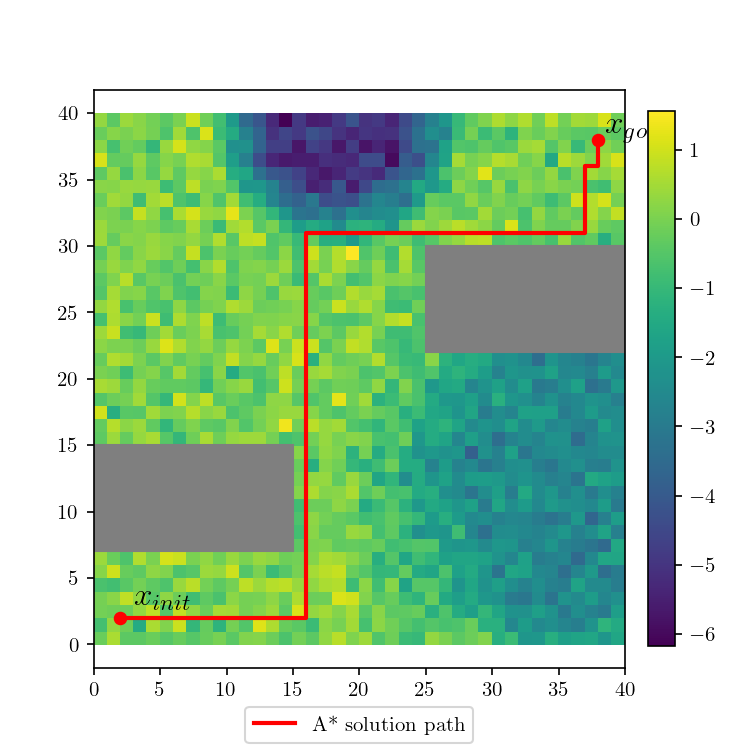

In [67]:
grid_obj = grid_env.get_grid()
resolution = grid_env.res

x_init = (2,2)
x_goal = (38,38)

# from AA274A --> needed lower bound tuple, upper bound tuple, initial state tuple, goal state tuple, occupancy as the grid, and resolution
# obstacles = [((6,7),(8,8)),((2,2),(4,3)),((2,5),(4,7)),((6,3),(8,5))]
obstacles = [((0,7),(15,15)), ((25,22),(40,30))]
astar = AStarPlanner((0, 0), (grid_env.N, grid_env.N), x_init, x_goal, grid_env, resolution, False, obstacles)

if not astar.solve():
    print("No path found")
else:
    path_plan = astar.path
    plt.rcParams['figure.figsize'] = [5, 5]
    astar.plot_path()
    # astar.plot_tree()